In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Dataset/hillstrom.csv")

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [4]:
df['treatment'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)

df[['segment','treatment']].head()

,segment,treatment
0,Womens E-Mail,1
1,No E-Mail,0
2,Womens E-Mail,1
3,Mens E-Mail,1
4,Womens E-Mail,1


In [5]:
df['treatment'].value_counts()

treatment
1    42694
0    21306
Name: count, dtype: int64

In [6]:
conversion_rates = df.groupby('treatment')['conversion'].mean()

print(conversion_rates)

treatment
0    0.005726
1    0.010681
Name: conversion, dtype: float64


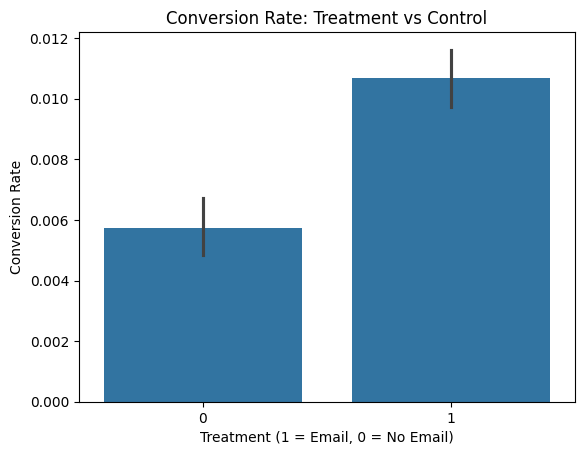

In [7]:
sns.barplot(x='treatment', y='conversion', data=df)

plt.title("Conversion Rate: Treatment vs Control")
plt.xlabel("Treatment (1 = Email, 0 = No Email)")
plt.ylabel("Conversion Rate")

plt.show()

In [8]:
treatment_group = df[df['treatment'] == 1]['conversion']
control_group = df[df['treatment'] == 0]['conversion']

t_stat, p_value = stats.ttest_ind(treatment_group, control_group)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 6.245570017455701
P-value: 4.2490162656914673e-10


If p-value < 0.05

We reject the null hypothesis.

This means the marketing email had a statistically significant impact on customer conversion.

In [9]:
uplift = treatment_group.mean() - control_group.mean()

print("Estimated uplift:", uplift)

Estimated uplift: 0.004954571155268468
